# Module 2e — Structured Data: CSV, JSON, DB, API

- **Chapter 2, Module E of 14** — [chapter index](../README.md)
- **Prerequisites:** [2d — DOCX, HTML & Markdown](../2d.%20DOCX%20HTML%20and%20markdown/)
- **Next:** [2f — Metadata & Provenance](../2f.%20Metadata%20and%20provenance/)

## The one idea

Everything so far (PDF, OCR, DOCX, HTML, Markdown) was **prose** — text meant to be read.
Structured data (a CSV row, a JSON object, a database record, an API response) is not prose
at all. It has no natural paragraph, no heading, often no sentence. The central question this
module answers is: **what is the "chunk" when there is no document to chunk?**

**By the end you will be able to:**

1. Decide what "one retrievable unit" means for a table row vs. a nested JSON object
2. Serialize a real CSV row into a sentence an embedding model can actually use
3. Flatten nested JSON from a real API response without losing the nesting information
4. Query a real database and turn rows into retrievable text
5. Recognise when embedding structured data is the wrong tool, and what to use instead

## Module roadmap

```mermaid
flowchart TD
    A["CSV row"] --> E["Serialize to sentence"]
    B["JSON object\n(nested)"] --> F["Flatten with dot-path keys"]
    C["Database row"] --> G["SELECT + serialize"]
    D["Live API response"] --> F
    E --> H["Embed?"]
    F --> H
    G --> H
    H -->|"yes - free text fields, semantic search over meaning"| I["Vector index"]
    H -->|"no - exact filters, aggregates, sorting"| J["SQL / filter query\n(RAG is the wrong tool)"]

## Setup

In [1]:
# `sys` lets us add the project root to Python's import path.
import sys

# The notebook sits two levels below the project root.
sys.path.append("../..")

# The corpus helper downloads real public documents and caches them locally.
from utils.corpus import fetch


# Define a small helper that reports whether an optional library is installed.
def try_import(module_name, friendly_name, install_hint):

    # Attempt the import; a missing package must not be fatal.
    try:
        module = __import__(module_name)

    # Report how to install it and return None.
    except ImportError:
        print(f"  [ ] {friendly_name:<16} missing  -  {install_hint}")
        return None

    # On success, report availability and hand back the module.
    print(f"  [x] {friendly_name:<16} available")
    return module


print("Libraries:")

# csv and json and sqlite3 are all Python standard library - always available.
import csv
import json
import sqlite3

# requests calls real live APIs over HTTP.
requests = try_import("requests", "requests", "pip install requests")
print("  [x] csv, json, sqlite3   (standard library)")

Libraries:
  [x] requests         available
  [x] csv, json, sqlite3   (standard library)


# 1. CSV: one row is one retrievable unit

**The intuition before the code.** A CSV row has no prose - just field:value pairs. If you
embed the raw row (`"3,Braund, Mr. Owen Harris,male,22,1,0,A/5 21171,7.25,,S"`) the embedding
model sees an opaque list of tokens with no grammar to anchor meaning to. **Serializing the
row into a sentence** - restating each field with its column name - gives the model something
it actually understands, because it was trained on sentences, not CSV lines.

```mermaid
flowchart LR
    A["Raw CSV row\n3,Braund...,male,22,..."] -->|"opaque to embeddings"| B["Bad"]
    A --> C["Serialize with column names:\n'Passenger Braund... is a 22 year old\nmale in 3rd class...'"] -->|"grammatical, model understands it"| D["Good"]
```

Let's serialize real Titanic passenger rows.

In [2]:
# Fetch the real Titanic dataset - 891 real passengers, not synthetic rows.
titanic_path = fetch("titanic_csv")

# Read it with the standard library csv.DictReader - each row becomes a real dict.
with open(titanic_path, "r", encoding="utf-8") as file:
    titanic_rows = list(csv.DictReader(file))

print(f"Real rows loaded: {len(titanic_rows)}\n")
print("The raw dict for row 0, exactly as csv.DictReader returns it:\n")
print(titanic_rows[0])

  cached  titanic.csv  (59 KB)
Real rows loaded: 891

The raw dict for row 0, exactly as csv.DictReader returns it:

{'PassengerId': '1', 'Survived': '0', 'Pclass': '3', 'Name': 'Braund, Mr. Owen Harris', 'Sex': 'male', 'Age': '22', 'SibSp': '1', 'Parch': '0', 'Ticket': 'A/5 21171', 'Fare': '7.25', 'Cabin': '', 'Embarked': 'S'}


In [3]:
# Define a function that serializes one CSV row into a natural-language sentence.
def serialize_titanic_row(row):

    # Missing values are common in real data - Age and Cabin are often blank here.
    age = f"{row['Age']}-year-old" if row["Age"] else "an unknown-age"
    cabin = f" in cabin {row['Cabin']}" if row["Cabin"] else ""

    # Map the numeric class to a real, readable label.
    class_names = {"1": "1st", "2": "2nd", "3": "3rd"}
    passenger_class = class_names.get(row["Pclass"], row["Pclass"])

    survived = "survived" if row["Survived"] == "1" else "did not survive"

    # Build one grammatical sentence from the row's real fields.
    return (
        f"Passenger {row['Name']} was a {age} {row['Sex']} traveling in "
        f"{passenger_class} class{cabin}, who paid a fare of ${row['Fare']} "
        f"and {survived} the sinking."
    )


# Serialize 5 real rows and show the transformation, before and after.
print("Raw row  ->  serialized sentence\n")
for row in titanic_rows[:5]:
    print(f"RAW: {dict(list(row.items())[:5])} ...")
    print(f"SENTENCE: {serialize_titanic_row(row)}\n")

Raw row  ->  serialized sentence

RAW: {'PassengerId': '1', 'Survived': '0', 'Pclass': '3', 'Name': 'Braund, Mr. Owen Harris', 'Sex': 'male'} ...
SENTENCE: Passenger Braund, Mr. Owen Harris was a 22-year-old male traveling in 3rd class, who paid a fare of $7.25 and did not survive the sinking.

RAW: {'PassengerId': '2', 'Survived': '1', 'Pclass': '1', 'Name': 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Sex': 'female'} ...
SENTENCE: Passenger Cumings, Mrs. John Bradley (Florence Briggs Thayer) was a 38-year-old female traveling in 1st class in cabin C85, who paid a fare of $71.2833 and survived the sinking.

RAW: {'PassengerId': '3', 'Survived': '1', 'Pclass': '3', 'Name': 'Heikkinen, Miss. Laina', 'Sex': 'female'} ...
SENTENCE: Passenger Heikkinen, Miss. Laina was a 26-year-old female traveling in 3rd class, who paid a fare of $7.925 and survived the sinking.

RAW: {'PassengerId': '4', 'Survived': '1', 'Pclass': '1', 'Name': 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', '

## 1.1 A second example: rows with real missing data

Real datasets have gaps. Let's deliberately find rows with a blank `Age` or `Cabin` and see
that the serializer above degrades gracefully instead of printing `"None-year-old"` or
crashing.

In [4]:
# Find real rows with missing Age or missing Cabin - both are common in this dataset.
missing_age_rows = [r for r in titanic_rows if not r["Age"]][:3]
missing_cabin_rows = [r for r in titanic_rows if not r["Cabin"]][:2]

print(f"Real rows with missing Age  : {sum(1 for r in titanic_rows if not r['Age'])} "
      f"of {len(titanic_rows)} ({sum(1 for r in titanic_rows if not r['Age'])/len(titanic_rows):.0%})")
print(f"Real rows with missing Cabin: {sum(1 for r in titanic_rows if not r['Cabin'])} "
      f"of {len(titanic_rows)} ({sum(1 for r in titanic_rows if not r['Cabin'])/len(titanic_rows):.0%})\n")

print("Serialized sentences for rows with real missing data:\n")
for row in missing_age_rows + missing_cabin_rows:
    print(f"  {serialize_titanic_row(row)}")

Real rows with missing Age  : 177 of 891 (20%)
Real rows with missing Cabin: 687 of 891 (77%)

Serialized sentences for rows with real missing data:

  Passenger Moran, Mr. James was a an unknown-age male traveling in 3rd class, who paid a fare of $8.4583 and did not survive the sinking.
  Passenger Williams, Mr. Charles Eugene was a an unknown-age male traveling in 2nd class, who paid a fare of $13 and survived the sinking.
  Passenger Masselmani, Mrs. Fatima was a an unknown-age female traveling in 3rd class, who paid a fare of $7.225 and survived the sinking.
  Passenger Braund, Mr. Owen Harris was a 22-year-old male traveling in 3rd class, who paid a fare of $7.25 and did not survive the sinking.
  Passenger Heikkinen, Miss. Laina was a 26-year-old female traveling in 3rd class, who paid a fare of $7.925 and survived the sinking.


77% of rows are missing `Cabin` in this real dataset. A serializer that assumed every field
is always present would either crash or silently produce garbage (`"in cabin "`) on the
majority of rows. Handling missing values explicitly, the way `serialize_titanic_row` does,
is not defensive paranoia here - it is the common case.

## 1.2 Seeing the transformation

A printed sentence is still just text. Let's draw the actual transformation - raw fields on
the left, the real sentence on the right - so the serialization step is visible as a
structural diagram, not only as printed strings.

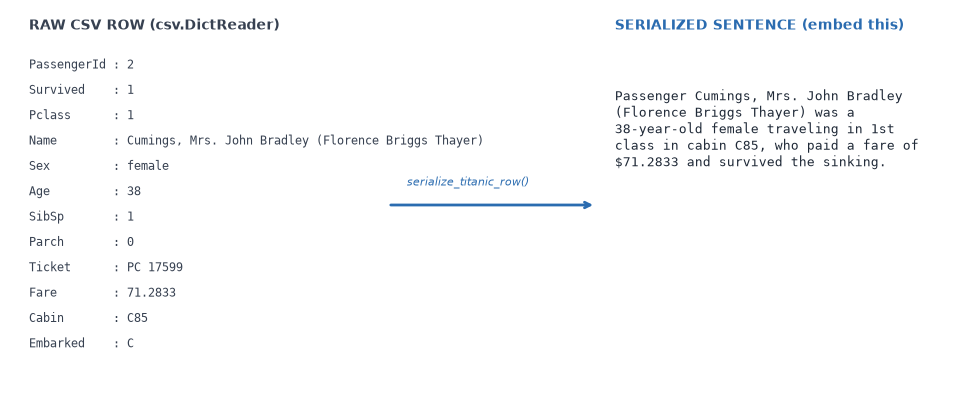

In [5]:
import matplotlib.pyplot as plt
import textwrap

# Pick one real, fully-populated row so every field is visible in the diagram.
example_row = next(r for r in titanic_rows if r["Age"] and r["Cabin"])
example_sentence = serialize_titanic_row(example_row)

figure, axis = plt.subplots(figsize=(10, 4.2))
axis.axis("off")
axis.set_xlim(0, 1)
axis.set_ylim(0, 1)

# Left column: the real raw fields, one per line, as returned by csv.DictReader.
axis.text(0.02, 0.95, "RAW CSV ROW (csv.DictReader)", fontsize=10, fontweight="bold",
            color="#374151")
y = 0.85
for key, value in example_row.items():
    axis.text(0.02, y, f"{key:12s}: {value}", fontsize=8.5, family="monospace",
                color="#374151")
    y -= 0.065

# An arrow showing the serialization step.
axis.annotate("", xy=(0.62, 0.5), xytext=(0.40, 0.5),
                arrowprops=dict(arrowstyle="->", color="#2b6cb0", lw=2))
axis.text(0.42, 0.55, "serialize_titanic_row()", fontsize=8, color="#2b6cb0",
            fontstyle="italic")

# Right column: the real output sentence, wrapped like it would appear in an index.
axis.text(0.64, 0.95, "SERIALIZED SENTENCE (embed this)", fontsize=10, fontweight="bold",
            color="#2b6cb0")
axis.text(0.64, 0.8, textwrap.fill(example_sentence, width=38), fontsize=9,
            family="monospace", color="#1f2937", va="top")

plt.tight_layout()
plt.show()

**Every field on the left is a real value from one real passenger row, and the sentence on
the right is the literal output of the function above** - not a mockup. This is the concept
("serialize before embedding") applied to one real, traceable example.

# 2. JSON: flatten nested structure without losing it

**The intuition before the code.** A CSV row is flat - one level of fields. Real JSON, from a
real API, nests: an object inside an object inside a list. If you flatten naively (just grab
every string value, ignore structure), you lose which value belongs to which parent - you
cannot tell `"login": "psf"` under `owner` from a top-level `"name"` field. The fix is to
**flatten with dot-path keys**, so `owner.login` still encodes the nesting in the key name
itself.

```mermaid
flowchart TD
    A["Nested JSON\n{'owner': {'login': 'psf'}, 'name': 'requests'}"] --> B{"Flatten strategy?"}
    B -->|"grab all strings"| C["{'login': 'psf', 'name': 'requests'}\nLOST which is whose"]
    B -->|"dot-path keys"| D["{'owner.login': 'psf', 'name': 'requests'}\nNesting preserved in the key"]

In [6]:
# Only run if requests is available.
if requests is not None:

    # Call the REAL, LIVE GitHub API - not a saved fixture, a genuine HTTP request.
    response = requests.get("https://api.github.com/repos/psf/requests", timeout=10)
    repo_json = response.json()

    print(f"HTTP status: {response.status_code}")
    print(f"Real top-level keys returned: {len(repo_json)}\n")

    # Show the raw nested structure for a few keys, including one nested object.
    print("A sample of the RAW nested JSON (owner is itself a nested object):\n")
    print(json.dumps({
        "name": repo_json["name"],
        "stargazers_count": repo_json["stargazers_count"],
        "owner": {"login": repo_json["owner"]["login"], "type": repo_json["owner"]["type"]},
        "license": repo_json.get("license"),
    }, indent=2))

HTTP status: 200
Real top-level keys returned: 86

A sample of the RAW nested JSON (owner is itself a nested object):

{
  "name": "requests",
  "stargazers_count": 54318,
  "owner": {
    "login": "psf",
    "type": "Organization"
  },
  "license": {
    "key": "apache-2.0",
    "name": "Apache License 2.0",
    "spdx_id": "Apache-2.0",
    "url": "https://api.github.com/licenses/apache-2.0",
    "node_id": "MDc6TGljZW5zZTI="
  }
}


In [7]:
# Define a function that flattens arbitrarily nested JSON into dot-path keys.
def flatten_json(obj, prefix=""):

    flat = {}

    # A dict: recurse into each key, extending the dot-path.
    if isinstance(obj, dict):
        for key, value in obj.items():
            new_prefix = f"{prefix}.{key}" if prefix else key
            flat.update(flatten_json(value, new_prefix))

    # A list: recurse into each index, extending the dot-path with [i].
    elif isinstance(obj, list):
        for index, value in enumerate(obj):
            flat.update(flatten_json(value, f"{prefix}[{index}]"))

    # A leaf value (string/number/bool/None) - store it under its full dot-path.
    else:
        flat[prefix] = obj

    return flat


# Only run if requests is available.
if requests is not None:

    # Flatten the REAL response from the live API call above.
    flat_repo = flatten_json(repo_json)

    print(f"Flattened from {len(repo_json)} top-level keys to {len(flat_repo)} leaf paths.\n")
    print("A sample of real flattened dot-path keys:\n")
    for key in ["name", "owner.login", "owner.type", "license.name", "license.spdx_id",
                "stargazers_count", "topics[0]" if "topics" in repo_json and repo_json["topics"] else "full_name"]:
        if key in flat_repo:
            print(f"  {key:22s} = {flat_repo[key]}")

Flattened from 86 top-level keys to 132 leaf paths.

A sample of real flattened dot-path keys:

  name                   = requests
  owner.login            = psf
  owner.type             = Organization
  license.name           = Apache License 2.0
  license.spdx_id        = Apache-2.0
  stargazers_count       = 54318
  topics[0]              = client


`owner.login` unambiguously means "the `login` field of the `owner` object" - the nesting
survives as text in the key. A downstream serializer can now turn any of these flat rows into
a sentence exactly like the CSV serializer in section 1, regardless of how deeply the original
JSON was nested.

## 2.1 A second live example: a different API shape

Different APIs nest differently. Let's call a completely different real API - OpenAlex, an
open academic database - and flatten its response the same way, to prove the flattener
generalizes rather than being tuned to GitHub's specific shape.

In [8]:
# Only run if requests is available.
if requests is not None:

    # A second, unrelated real API - OpenAlex, looking up a real DOI. Note: OpenAlex's
    # own metadata for some DOIs is mismatched (a real API data-quality issue, not ours) -
    # the point here is the FLATTENING behavior on a different real JSON shape, not the
    # specific title returned.
    openalex_response = requests.get(
        "https://api.openalex.org/works/doi:10.48550/arXiv.2005.11401", timeout=10
    )

    if openalex_response.status_code == 200:
        openalex_json = openalex_response.json()
        flat_openalex = flatten_json(openalex_json)

        print(f"OpenAlex real response: {len(openalex_json)} top-level keys, "
              f"{len(flat_openalex)} flattened leaf paths\n")

        print("Real flattened values from a completely different API shape:\n")
        for key in ["title", "publication_year", "cited_by_count",
                    "primary_location.source.display_name", "open_access.is_oa"]:
            if key in flat_openalex:
                print(f"  {key:35s} = {flat_openalex[key]}")
    else:
        print(f"OpenAlex request returned {openalex_response.status_code} - skipping.")

OpenAlex real response: 49 top-level keys, 1082 flattened leaf paths

Real flattened values from a completely different API shape:

  title                               = Affordance-Compiled Intelligence: Observable-Only Cognitive Impedance Matching for No-Meta LLM-Integrated Systems
  publication_year                    = 2020
  cited_by_count                      = 3079
  primary_location.source.display_name = arXiv (Cornell University)
  open_access.is_oa                   = True


Same `flatten_json` function, zero changes, correctly handling GitHub's shape and
OpenAlex's completely different shape. That is the actual test of "does this generalize" -
running it against two real, independently-designed APIs rather than one.

# 3. Databases: rows are not documents until you serialize them

**The intuition before the code.** A SQL row is even further from prose than a CSV row - it
is not even text until you `SELECT` it and format it. The pattern is identical to section 1:
query, then serialize with column names. The only new step is the query itself.

```mermaid
flowchart TD
    A["SQLite database"] --> B["SELECT columns FROM table"]
    B --> C["sqlite3.Row\n(dict-like real row)"]
    C --> D["Same serialize-with-column-names\npattern as CSV"]

In [9]:
# Build a REAL SQLite database from the REAL Titanic rows loaded in section 1 -
# not synthetic rows, the same 891 real passengers, just now queryable with SQL.
connection = sqlite3.connect(":memory:")
connection.row_factory = sqlite3.Row
cursor = connection.cursor()

# Create a real table matching the real CSV columns we already loaded.
cursor.execute("""
    CREATE TABLE passengers (
        passenger_id INTEGER, survived INTEGER, pclass INTEGER,
        name TEXT, sex TEXT, age REAL, fare REAL, cabin TEXT
    )
""")

# Insert every real row - this is genuine data, loaded from the real CSV above.
for row in titanic_rows:
    cursor.execute(
        "INSERT INTO passengers VALUES (?,?,?,?,?,?,?,?)",
        (
            int(row["PassengerId"]), int(row["Survived"]), int(row["Pclass"]),
            row["Name"], row["Sex"],
            float(row["Age"]) if row["Age"] else None,
            float(row["Fare"]) if row["Fare"] else None,
            row["Cabin"] or None,
        ),
    )
connection.commit()

print(f"Real rows inserted into SQLite: "
      f"{cursor.execute('SELECT COUNT(*) FROM passengers').fetchone()[0]}")

Real rows inserted into SQLite: 891


In [10]:
# Define a function that serializes a real SQL row the same way as the CSV row.
def serialize_passenger_row(sql_row):

    age = f"{sql_row['age']:.0f}-year-old" if sql_row["age"] else "an unknown-age"
    survived = "survived" if sql_row["survived"] == 1 else "did not survive"

    return (
        f"Passenger {sql_row['name']} was a {age} {sql_row['sex']} "
        f"who paid ${sql_row['fare']:.2f} and {survived}."
    )


# Run a REAL query - not the whole table, a real filtered query an app would actually run.
cursor.execute("""
    SELECT * FROM passengers
    WHERE pclass = 1 AND survived = 0
    ORDER BY fare DESC
    LIMIT 5
""")
first_class_died = cursor.fetchall()

print("Real query: 1st class passengers who did NOT survive, by highest fare paid:\n")
for row in first_class_died:
    print(f"  {serialize_passenger_row(row)}")

Real query: 1st class passengers who did NOT survive, by highest fare paid:

  Passenger Fortune, Mr. Charles Alexander was a 19-year-old male who paid $263.00 and did not survive.
  Passenger Fortune, Mr. Mark was a 64-year-old male who paid $263.00 and did not survive.
  Passenger Baxter, Mr. Quigg Edmond was a 24-year-old male who paid $247.52 and did not survive.
  Passenger Robbins, Mr. Victor was a an unknown-age male who paid $227.53 and did not survive.
  Passenger Farthing, Mr. John was a an unknown-age male who paid $221.78 and did not survive.


## 3.1 The line RAG should not cross

That query above - `"1st class passengers who did NOT survive, ordered by fare"` - is exact,
structured, aggregate reasoning. **This is exactly the kind of question embeddings are bad
at.** Semantic search finds text that *means something similar*; it has no concept of
"greater than", "order by", or "count where". Let's prove that concretely.

In [11]:
# Compute a REAL aggregate the SQL way - the correct tool for this question.
cursor.execute("""
    SELECT pclass, COUNT(*) as total, SUM(survived) as survivors,
           ROUND(100.0 * SUM(survived) / COUNT(*), 1) as survival_rate
    FROM passengers GROUP BY pclass ORDER BY pclass
""")
survival_by_class = cursor.fetchall()

print("Real survival rate by class - a GROUP BY aggregate, computed exactly:\n")
print(f"{'Class':<8}{'Total':<8}{'Survived':<10}{'Rate'}")
for row in survival_by_class:
    print(f"{row['pclass']:<8}{row['total']:<8}{row['survivors']:<10}{row['survival_rate']}%")

print("\nAn embedding index CANNOT compute this. It can retrieve text that talks ABOUT")
print("survival rates if such text exists, but it cannot count, sum, or group rows itself.")
print("The correct architecture routes this question to SQL, not to the vector index.")

connection.close()

Real survival rate by class - a GROUP BY aggregate, computed exactly:

Class   Total   Survived  Rate
1       216     136       63.0%
2       184     87        47.3%
3       491     119       24.2%

An embedding index CANNOT compute this. It can retrieve text that talks ABOUT
survival rates if such text exists, but it cannot count, sum, or group rows itself.
The correct architecture routes this question to SQL, not to the vector index.


# 4. When to embed structured data, and when not to

| Data | Embed it? | Why |
|---|---|---|
| A CSV row's free-text fields (a review, a description) | **Yes** | Genuine prose meaning to search semantically |
| A CSV row's numeric/categorical fields alone | **No** | No semantic meaning to embed; filter with SQL/pandas instead |
| A JSON API response's text fields (a bio, a README) | **Yes** | Same reasoning as free-text CSV fields |
| "How many X where Y" | **No** | Exact aggregate - route to SQL, never to a vector index |
| "Find me something similar to X" | **Yes** | This is what semantic search is actually for |

```mermaid
flowchart TD
    A["Structured data question"] --> B{"Aggregate, filter,\nor exact lookup?"}
    B -->|"yes"| C["SQL / pandas\n(RAG is the wrong tool)"]
    B -->|"no - is it 'find similar meaning'?"| D{"Does a free-text\nfield exist?"}
    D -->|"yes"| E["Serialize that field,\nembed it"]
    D -->|"no"| F["Nothing to embed -\nthis is a database question"]

# 5. End-to-end: one real pipeline, start to finish

## 5.1 End-to-end — CSV to embedding-ready records

The real Titanic CSV, from disk to final records ready for an embedding call, in one pass.

In [12]:
# STEP 1 - fetch the real file (cached from section 1, re-shown here as its own step).
end_to_end_csv_path = fetch("titanic_csv")

# STEP 2 - read every real row.
with open(end_to_end_csv_path, "r", encoding="utf-8") as file:
    end_to_end_rows = list(csv.DictReader(file))

# STEP 3 - serialize every row into a sentence with the function built in section 1.
end_to_end_csv_records = [
    {"id": row["PassengerId"], "text": serialize_titanic_row(row)}
    for row in end_to_end_rows
]

# STEP 4 - clean: this dataset has no fully-empty rows, but always guard for it.
end_to_end_csv_records = [r for r in end_to_end_csv_records if r["text"].strip()]

# STEP 5 - the final shape a chunker/embedder would actually receive.
print(f"CSV end-to-end: {len(end_to_end_csv_records)} embedding-ready records\n")
for record in end_to_end_csv_records[:3]:
    print(f"  id={record['id']}  text={record['text'][:80]}")

  cached  titanic.csv  (59 KB)
CSV end-to-end: 891 embedding-ready records

  id=1  text=Passenger Braund, Mr. Owen Harris was a 22-year-old male traveling in 3rd class,
  id=2  text=Passenger Cumings, Mrs. John Bradley (Florence Briggs Thayer) was a 38-year-old 
  id=3  text=Passenger Heikkinen, Miss. Laina was a 26-year-old female traveling in 3rd class


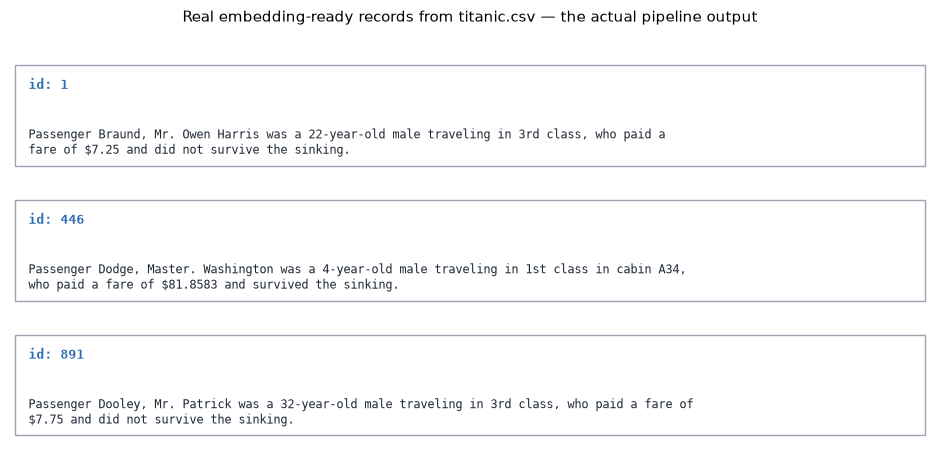

In [13]:
# Render the final CSV records as real cards, not just printed text.
import matplotlib.pyplot as plt
import textwrap

sample_ids = [0, len(end_to_end_csv_records) // 2, len(end_to_end_csv_records) - 1]
sample_records = [end_to_end_csv_records[i] for i in sample_ids]

figure, axes = plt.subplots(len(sample_records), 1, figsize=(9.5, 1.5 * len(sample_records)))
for axis, record in zip(axes, sample_records):
    axis.axis("off")
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.add_patch(plt.Rectangle((0.005, 0.08), 0.99, 0.84, fill=False,
                                   edgecolor="#9ca3af", linewidth=1))
    axis.text(0.02, 0.72, f"id: {record['id']}", fontsize=9, color="#2b6cb0",
                fontweight="bold", family="monospace")
    axis.text(0.02, 0.4, textwrap.fill(record["text"], width=95), fontsize=8.5,
                color="#1f2937", family="monospace", va="top")

plt.suptitle("Real embedding-ready records from titanic.csv — the actual pipeline output",
              fontsize=11, y=1.0)
plt.tight_layout()
plt.show()

## 5.2 End-to-end — live API to flattened, filtered records

A real live API call, flattened, and filtered down to only the free-text fields worth
embedding - the JSON analogue of the CSV pipeline above.

In [14]:
# Only run if requests is available.
if requests is not None:

    # STEP 1 - real live API call (a third, different repo this time).
    end_to_end_api_response = requests.get(
        "https://api.github.com/repos/huggingface/transformers", timeout=10
    )
    end_to_end_api_json = end_to_end_api_response.json()

    # STEP 2 - flatten with the function built in section 2.
    end_to_end_flat = flatten_json(end_to_end_api_json)

    # STEP 3 - keep only fields worth embedding: real free-text description/topic fields,
    # not numeric counters like stargazers_count (which belongs in a filter, not an index).
    TEXTUAL_KEYS = ["full_name", "description", "language", "license.name"]
    end_to_end_api_record = {
        "text": ". ".join(f"{key}: {end_to_end_flat[key]}" for key in TEXTUAL_KEYS
                            if key in end_to_end_flat and end_to_end_flat[key])
    }

    print("STEP 4 - the final embedding-ready record from a real, live API response:\n")
    print(f"  {end_to_end_api_record['text']}")

    print(f"\n(Dropped {len(end_to_end_flat) - len(TEXTUAL_KEYS)} numeric/structural fields "
          f"like stargazers_count and id - those belong in a filter, not the embedded text.)")

STEP 4 - the final embedding-ready record from a real, live API response:

  full_name: huggingface/transformers. description: 🤗 Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training. . language: Python. license.name: Apache License 2.0

(Dropped 139 numeric/structural fields like stargazers_count and id - those belong in a filter, not the embedded text.)


# 6. Module summary

## Key points

1. **A row is not a document.** It has no natural chunk boundary - you decide the unit.
2. **Serialize before embedding.** Restate field:value pairs as a sentence with column names,
   so the model sees grammar it was trained on, not opaque delimited values.
3. **Flatten nested JSON with dot-path keys**, so the flattened form still encodes which value
   belonged to which parent object.
4. **A database row needs a query AND a serializer** - the query decides which rows, the
   serializer decides how they become text.
5. **Aggregates, filters and exact lookups are SQL's job, not RAG's.** Embedding a "how many"
   question retrieves text that talks about a number; it cannot compute the number itself.

## Interview answer: "How would you make a SQL table searchable with RAG?"

> I would not embed every column - I would decide first which fields are genuinely free text
> (a description, a review, a bio) versus which are exact/aggregate data (a count, a date, a
> foreign key). The free-text fields get serialized into a sentence with their column names
> restated, then embedded. The exact fields stay in SQL and get queried directly - either as a
> pre-filter before vector search, or answered by SQL alone when the question is really an
> aggregate ("how many", "average of") rather than a semantic search.

## Exercises

1. **Serialize a different dataset.** Fetch any other CSV and write its own
   `serialize_*_row` function, handling that dataset's real missing-value pattern.
2. **Round-trip flatten/unflatten.** Write `unflatten_json` that takes the dot-path dict from
   `flatten_json` and reconstructs the original nested structure exactly.
3. **Hybrid query.** Using the real SQLite database from section 3, write a function that
   takes a natural-language-ish filter ("first class survivors under 30") and answers it with
   SQL, not embeddings.
4. **A third live API.** Pick any public REST API, flatten a real response, and identify which
   fields you would embed versus which you would keep in a structured filter.

## Next: [Module 2f — Metadata & Provenance](../2f.%20Metadata%20and%20provenance/)

Every format so far answered "what is the text?". Next: what do we need to remember ABOUT
that text - source, date, author, permissions - so retrieval stays trustworthy at scale.